# Exact-event EB evidence confidence screen

## 가설

`gene__normalized_event` EB가 만든 암종별 점수는 유지하되, 각 점수가 많은 약한 사건인지 소수의 강한 사건인지와 posterior support 신뢰도를 제공하면 정확 변이 증거의 과신을 줄일 수 있다.

## 변경하지 않는 조건

- 기준: accepted exact-event EB H0 branch
- LR `lbfgs`, `C=0.07`, `max_iter=2000`, `class_weight='balanced'`
- H0 `0.80 × LR + 0.20 × automatic LGBM specialist`
- selective margin `0.05`; 새 blend·threshold 탐색 없음

## 누수·대회 규칙

- 이 seed42 screen은 `train.csv`만 읽으며 test를 열지 않는다.
- exact vocabulary, EB posterior, reliability, standardization은 outer-fold train 및 그 내부 OOF에서만 fit한다.
- 고정 암종·유전자·변이 목록은 없고, WT/blank/NaN은 event가 아니다.
- `leakage_check=True`, `nan_as_mutation_count=0`을 결과에 기록한다.

## 승격 기준

exact-event EB 대비 Macro F1 `+0.008` 이상, 5 fold 중 4개 이상 상승, 최저 클래스 F1 변화 `-0.05` 이상일 때만 3-seed로 확장한다.

In [1]:
from pathlib import Path
import subprocess, sys
from tqdm.auto import tqdm

ROOT = Path('/Users/admin/Documents/FinalProject/OZ_fianl_hackaton')
BASE = ROOT / 'experiments' / 'gs' / 'notebooks' / 'exp_model_016'
RUNNER = BASE / 'common' / 'run_exact_evidence_confidence_screen.py'
RESULT = BASE / 'result'
RUN_ID = 'exp-exact-evidence-confidence-01'
SEED = 42
RUN_EXPERIMENT = True
assert RUNNER.exists()
print({'runner': RUNNER, 'seed': SEED, 'test_read': False, 'new_feature': 'fold_train_exact_evidence_shape'})

{'runner': PosixPath('/Users/admin/Documents/FinalProject/OZ_fianl_hackaton/experiments/gs/notebooks/exp_model_016/common/run_exact_evidence_confidence_screen.py'), 'seed': 42, 'test_read': False, 'new_feature': 'fold_train_exact_evidence_shape'}


/Users/admin/Documents/FinalProject/OZ_fianl_hackaton/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
if RUN_EXPERIMENT:
    process = subprocess.Popen([sys.executable, str(RUNNER), '--run-id', RUN_ID, '--seed', str(SEED)], stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True, bufsize=1)
    tail = []
    for line in tqdm(process.stdout, desc='exact confidence screen', unit='line'):
        print(line, end='')
        tail = (tail + [line])[-120:]
    if process.wait():
        raise RuntimeError('confidence screen failed:\n' + ''.join(tail))
else:
    print('RUN_EXPERIMENT=False: existing result files only.')

exact confidence screen: 1line [00:05,  5.29s/line]

[exact evidence confidence] seed 42, fold 1/5


exact confidence screen: 2line [07:10, 252.09s/line]

[exact evidence confidence] seed 42, fold 2/5


exact confidence screen: 3line [14:41, 343.01s/line]

...

exact confidence screen: 5line [31:05, 438.51s/line]

[exact evidence confidence] seed 42, fold 5/5


exact confidence screen: 6line [38:31, 441.14s/line]

{"run_id": "exp-exact-evidence-confidence-01", "seed": 42, "delta_required": 0.008, "delta_vs_exact_event_eb": -0.012067427568581257, "positive_fold_count": 0, "minimum_class_delta": -0.1485826001955035, "screen_pass": false, "test_read": false, "train_test_concat": false, "fixed_class_gene_exact_mutation_rules": false, "leakage_check": true, "nan_as_mutation_count": 0}


exact confidence screen: 6line [38:31, 385.31s/line]


In [3]:
import json
import matplotlib.pyplot as plt
import pandas as pd

summary = pd.read_csv(RESULT / f'{RUN_ID}_seed{SEED}_summary.csv')
folds = pd.read_csv(RESULT / f'{RUN_ID}_seed{SEED}_fold_metrics.csv')
classes = pd.read_csv(RESULT / f'{RUN_ID}_seed{SEED}_class_metrics.csv')
audit = json.loads((RESULT / f'{RUN_ID}_seed{SEED}_leakage_audit.json').read_text())
assert summary.leakage_check.all() and summary.nan_as_mutation_count.eq(0).all()
display(summary)
display(folds.pivot(index='fold', columns='variant', values='macro_f1'))
display(classes.pivot(index='class', columns='variant', values='f1').assign(delta=lambda x: x['exact_event_EB_confidence'] - x['exact_event_EB']).sort_values('delta'))
print(audit)

,seed,variant,oof_macro_f1,oof_accuracy,feature_count_mean,convergence_warning_count,leakage_check,nan_as_mutation_count,runtime_seconds,delta_vs_exact_event_eb
0,42,exact_event_EB,0.570154,0.584906,8245.2,0,True,0,2305.161422,0.000000
1,42,exact_event_EB_confidence,0.558086,0.579584,8479.2,0,True,0,2305.186268,-0.012067


variant,exact_event_EB,exact_event_EB_confidence
fold,,
1,0.560260,0.556529
2,0.567198,0.553968
3,0.560603,0.549206
4,0.565532,0.564913
5,0.595970,0.560362


variant,exact_event_EB,exact_event_EB_confidence,delta
class,,,
DLBC,0.696970,0.548387,-0.148583
HNSC,0.397059,0.365432,-0.031627
UCEC,0.646766,0.624365,-0.022401
LAML,0.585034,0.563758,-0.021276
COAD,0.774049,0.755459,-0.018591
LIHC,0.472393,0.456592,-0.015801
SKCM,0.893130,0.878049,-0.015081
PCPG,0.424731,0.410811,-0.013920
TGCT,0.704545,0.691450,-0.013096


{'run_id': 'exp-exact-evidence-confidence-01', 'seed': 42, 'delta_required': 0.008, 'delta_vs_exact_event_eb': -0.012067427568581257, 'positive_fold_count': 0, 'minimum_class_delta': -0.1485826001955035, 'screen_pass': False, 'test_read': False, 'train_test_concat': False, 'fixed_class_gene_exact_mutation_rules': False, 'leakage_check': True, 'nan_as_mutation_count': 0}


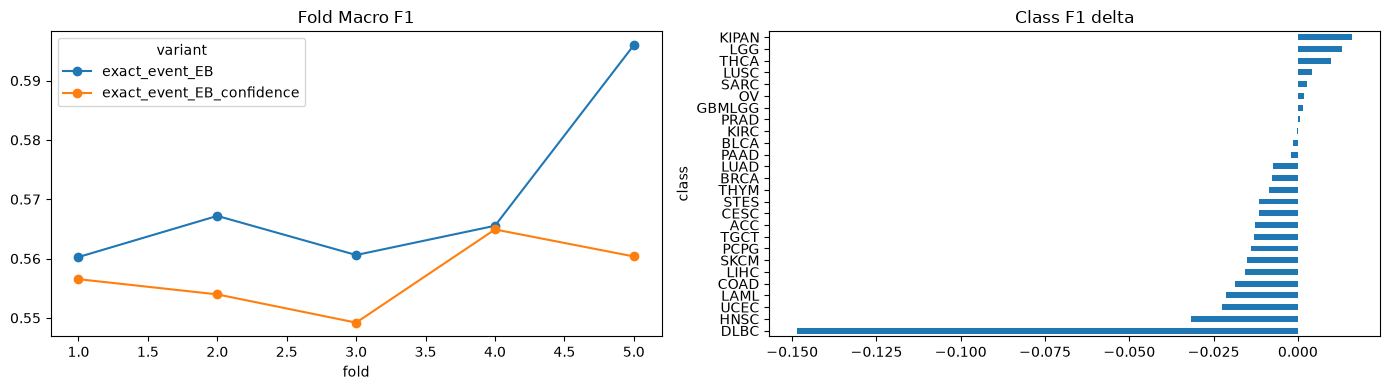

{'decision': '미검출/기각', 'delta': -0.0120674275685812, 'positive_folds': 0, 'minimum_class_delta': -0.1485826001955035}


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
folds.pivot(index='fold', columns='variant', values='macro_f1').plot(marker='o', ax=axes[0], title='Fold Macro F1')
class_delta = classes.pivot(index='class', columns='variant', values='f1')['exact_event_EB_confidence'] - classes.pivot(index='class', columns='variant', values='f1')['exact_event_EB']
class_delta.sort_values().plot.barh(ax=axes[1], title='Class F1 delta')
plt.tight_layout(); plt.show()

positive_folds = int((folds.pivot(index='fold', columns='variant', values='macro_f1')['exact_event_EB_confidence'] > folds.pivot(index='fold', columns='variant', values='macro_f1')['exact_event_EB']).sum())
candidate_delta = float(summary.loc[summary.variant.eq('exact_event_EB_confidence'), 'delta_vs_exact_event_eb'].iloc[0])
decision = '3-seed 검증 후보' if candidate_delta >= 0.008 and positive_folds >= 4 and audit['minimum_class_delta'] >= -0.05 else '미검출/기각'
print({'decision': decision, 'delta': candidate_delta, 'positive_folds': positive_folds, 'minimum_class_delta': audit['minimum_class_delta']})